In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ---------- config ----------
PAIR = "EUR/USD"
SYMBOL = "eurusd"  # file prefix used by p_duka: eurusd_dukascopy_{bid,ask}_YYYYMM.parquet

START_YYYYMM = "201901"
END_YYYYMM = "202604"   # set to your latest month you want included

AVG_WINDOW_TICKS = 100  # rolling mean window (ticks)
STRIDE_TICKS = 100      # take every Nth tick after rolling mean

DROP_ZERO_RETURNS = True
CLIP_Q = None  # e.g. (0.001, 0.999) or set None to disable clipping

print("IN_COLAB:", IN_COLAB)

IN_COLAB: True


In [2]:
if IN_COLAB:
    drive.mount("/content/drive", force_remount=True)
    TICK_DIR = Path("/content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed")
    OUT_DIR  = Path("/content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed_mega")
else:
    TICK_DIR = Path("../data/processed")
    OUT_DIR  = Path("../data/processed_mega")

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("TICK_DIR:", TICK_DIR)
print("OUT_DIR:", OUT_DIR)

Mounted at /content/drive
TICK_DIR: /content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed
OUT_DIR: /content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed_mega


In [3]:
def month_list(start_ym: str, end_ym: str):
    y0, m0 = int(start_ym[:4]), int(start_ym[4:6])
    y1, m1 = int(end_ym[:4]), int(end_ym[4:6])
    out = []
    y, m = y0, m0
    while (y < y1) or (y == y1 and m <= m1):
        out.append(f"{y}{m:02d}")
        if m == 12:
            y, m = y + 1, 1
        else:
            m += 1
    return out

# Available months on disk (best-effort: only months with both bid+ask files)
pat = re.compile(rf"^{re.escape(SYMBOL)}_dukascopy_(bid|ask)_(\d{{6}})\.parquet$", re.I)

bid_months, ask_months = set(), set()
for fp in TICK_DIR.glob(f"{SYMBOL}_dukascopy_*_*.parquet"):
    m = pat.match(fp.name)
    if not m:
        continue
    side = m.group(1).lower()
    ym = m.group(2)
    (bid_months if side == "bid" else ask_months).add(ym)

wanted = set(month_list(START_YYYYMM, END_YYYYMM))
months = sorted(list(wanted & bid_months & ask_months))

print(f"Months wanted: {len(wanted)}")
print(f"Months with both bid+ask available: {len(months)}")
print("First/last month:", months[0], months[-1] if months else None)

Months wanted: 88
Months with both bid+ask available: 88
First/last month: 201901 202604


In [4]:
def process_month(yyyymm: str) -> pd.DataFrame:
    bid_path = TICK_DIR / f"{SYMBOL}_dukascopy_bid_{yyyymm}.parquet"
    ask_path = TICK_DIR / f"{SYMBOL}_dukascopy_ask_{yyyymm}.parquet"

    b = pd.read_parquet(bid_path, columns=["datetime", "price"]).rename(columns={"price": "bid"})
    a = pd.read_parquet(ask_path, columns=["datetime", "price"]).rename(columns={"price": "ask"})

    b["datetime"] = pd.to_datetime(b["datetime"], utc=False)
    a["datetime"] = pd.to_datetime(a["datetime"], utc=False)

    b = b.sort_values("datetime").drop_duplicates("datetime", keep="last")
    a = a.sort_values("datetime").drop_duplicates("datetime", keep="last")

    df = pd.merge_asof(b, a, on="datetime", direction="backward")
    df["mid"] = (df["bid"] + df["ask"]) / 2.0
    df["returns"] = np.log(df["mid"] / df["mid"].shift(1))

    if DROP_ZERO_RETURNS:
        df = df[df["returns"] != 0]

    df = df.dropna(subset=["returns", "datetime"])

    if CLIP_Q is not None:
        lo, hi = df["returns"].quantile(CLIP_Q[0]), df["returns"].quantile(CLIP_Q[1])
        df["returns"] = df["returns"].clip(lo, hi)

    # Pre-averaging style used in earlier hw: rolling mean then stride
    df = df.sort_values("datetime")
    df["returns"] = df["returns"].rolling(AVG_WINDOW_TICKS).mean()
    df = df.iloc[::STRIDE_TICKS].dropna(subset=["returns"])

    df = df[["datetime", "returns"]].copy()
    df["date"] = df["datetime"].dt.date.astype(str)
    df["yyyymm"] = yyyymm
    return df

In [5]:
pieces = []
for i, ym in enumerate(months, 1):
    print(f"[{i}/{len(months)}] processing {ym} ...", flush=True)
    try:
        part = process_month(ym)
        pieces.append(part)
    except Exception as e:
        print(f"  ERROR {ym}: {e}")

master_df = pd.concat(pieces, ignore_index=True).sort_values("datetime").reset_index(drop=True)

print("master_df rows:", len(master_df))
print("datetime range:", master_df["datetime"].min(), "->", master_df["datetime"].max())
master_df.head()

[1/88] processing 201901 ...
[2/88] processing 201902 ...
[3/88] processing 201903 ...
[4/88] processing 201904 ...
[5/88] processing 201905 ...
[6/88] processing 201906 ...
[7/88] processing 201907 ...
[8/88] processing 201908 ...
[9/88] processing 201909 ...
[10/88] processing 201910 ...
[11/88] processing 201911 ...
[12/88] processing 201912 ...
[13/88] processing 202001 ...
[14/88] processing 202002 ...
[15/88] processing 202003 ...
[16/88] processing 202004 ...
[17/88] processing 202005 ...
[18/88] processing 202006 ...
[19/88] processing 202007 ...
[20/88] processing 202008 ...
[21/88] processing 202009 ...
[22/88] processing 202010 ...
[23/88] processing 202011 ...
[24/88] processing 202012 ...
[25/88] processing 202101 ...
[26/88] processing 202102 ...
[27/88] processing 202103 ...
[28/88] processing 202104 ...
[29/88] processing 202105 ...
[30/88] processing 202106 ...
[31/88] processing 202107 ...
[32/88] processing 202108 ...
[33/88] processing 202109 ...
[34/88] processing 

,datetime,returns,date,yyyymm
0,2019-01-01 22:07:11.272000+00:00,2.485723e-06,2019-01-01,201901
1,2019-01-01 22:14:49.348000+00:00,-2.747415e-06,2019-01-01,201901
2,2019-01-01 22:21:42.307000+00:00,-1.003212e-06,2019-01-01,201901
3,2019-01-01 22:28:13.309000+00:00,-2.181030e-07,2019-01-01,201901
4,2019-01-01 22:33:34.800000+00:00,-2.181077e-07,2019-01-01,201901


In [6]:
avg_tag = f"avg{AVG_WINDOW_TICKS}_stride{STRIDE_TICKS}"
out_name = f"{SYMBOL}_master_returns_{START_YYYYMM}_{END_YYYYMM}_{avg_tag}.parquet"
master_path = OUT_DIR / out_name

master_df.to_parquet(master_path, index=False)
print("Saved:", master_path)

Saved: /content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed_mega/eurusd_master_returns_201901_202604_avg100_stride100.parquet


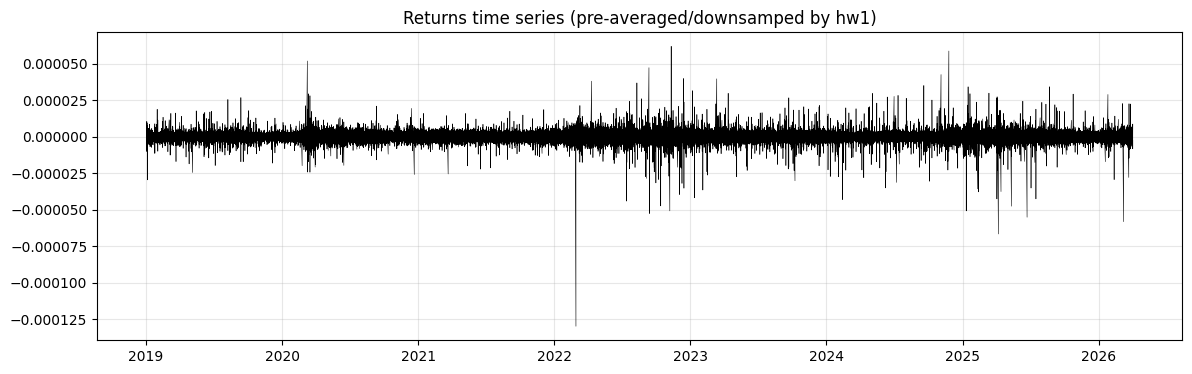

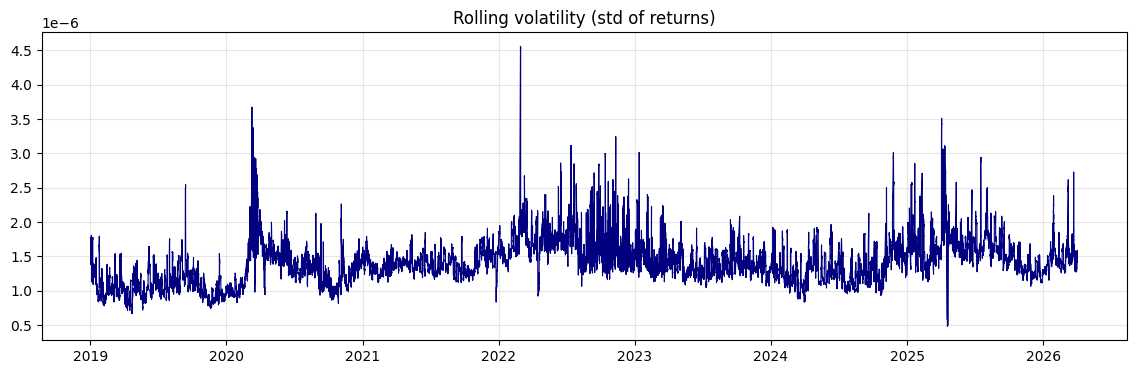

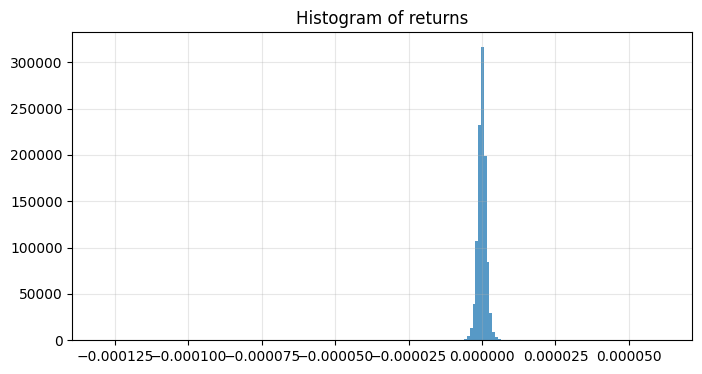

In [7]:
plt.figure(figsize=(14,4))
plt.plot(master_df["datetime"], master_df["returns"], lw=0.4, color="black")
plt.title("Returns time series (pre-averaged/downsamped by hw1)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14,4))
roll = master_df["returns"].rolling(1000).std()
plt.plot(master_df["datetime"], roll, lw=0.8, color="navy")
plt.title("Rolling volatility (std of returns)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,4))
plt.hist(master_df["returns"].values, bins=200, density=True, alpha=0.75)
plt.title("Histogram of returns")
plt.grid(alpha=0.3)
plt.show()

In [8]:
daily = master_df.groupby("date").size().rename("n_obs").reset_index()
print("Daily rows:", len(daily), "days")
display(daily.describe())

# Save for convenience (optional)
day_path = master_path.with_name(master_path.stem + "_daily_counts.parquet")
daily.to_parquet(day_path, index=False)
print("Saved:", day_path)

Daily rows: 2269 days


,n_obs
count,2269.000000
mean,813.526223
std,538.136410
min,1.000000
25%,527.000000
50%,789.000000
75%,1074.000000
max,3832.000000


Saved: /content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed_mega/eurusd_master_returns_201901_202604_avg100_stride100_daily_counts.parquet
